# Analysis of the dataset
in this part we will analize our datasets 

In [1]:
import pandas as pd

train = pd.read_csv("development.csv")
test = pd.read_csv("evaluation.csv")

print(f"shape of the training set: ", train.shape)
print(f"shape of the test set: ", test.shape)

shape of the training set:  (7284, 47)
shape of the test set:  (1821, 46)


In [2]:
train

,age,sex,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,...,bun,urine,adlp,adls,adlsc,medical_center,admission_month,temp_f,death,Id
0,74.51599,female,MOSF w/Malig,ARF/MOSF,2,13.0,under $11k,26.0,48918.0,30905.7188,...,18.0,2950.0,NaN,0.0,0.000000,MC3,Dec,98.051558,1,0
1,55.01398,male,Lung Cancer,Cancer,2,4.0,$11-$25k,0.0,6700.0,4328.8984,...,10.0,3910.0,3.0,3.0,3.000000,MC3,Oct,100.934384,1,1
2,45.41800,male,Lung Cancer,Cancer,2,NaN,NaN,0.0,8400.0,NaN,...,NaN,NaN,NaN,NaN,3.351562,MC1,Feb,99.134384,1,2
3,73.61798,male,MOSF w/Malig,ARF/MOSF,1,16.0,>$50k,41.0,86043.0,39136.6875,...,15.0,2410.0,NaN,5.0,5.000000,MC1,Aug,96.800000,1,3
4,67.92596,female,MOSF w/Malig,ARF/MOSF,1,NaN,NaN,44.0,320408.0,67552.1250,...,25.0,2305.0,NaN,NaN,2.764648,MC3,Mar,102.200000,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7279,58.85797,female,Coma,Coma,1,10.0,NaN,55.0,116164.0,109721.8120,...,10.0,2450.0,NaN,0.0,0.000000,MC1,Aug,96.617192,1,7279
7280,27.13799,male,ARF/MOSF w/Sepsis,ARF/MOSF,0,16.0,NaN,0.0,30684.0,20034.7188,...,17.0,800.0,0.0,0.0,0.000000,MC4,Oct,98.234384,0,7280
7281,56.64099,female,Coma,Coma,3,NaN,NaN,9.0,27058.0,18051.0000,...,26.0,3252.0,NaN,7.0,7.000000,MC2,May,101.651558,0,7281
7282,58.40097,female,Cirrhosis,COPD/CHF/Cirrhosis,4,14.0,under $11k,0.0,5292.0,3863.1250,...,NaN,NaN,1.0,NaN,1.166900,MC2,Jun,97.151558,1,7282


#### We can already notice that there's a feature called 'Id' which is redundant so we can delete it

In [3]:
train = train.drop(columns='Id')
test = test.drop(columns = 'Id')

## Target balance 
### -> 1: 0.681, 0: 0.319 not balanced, we need to rebalance or use other thresholds values to obtain better results

In [4]:
print(f"Target balance : {train['death'].value_counts(normalize=True).round(3).to_dict()}")

Target balance : {1: 0.681, 0: 0.319}


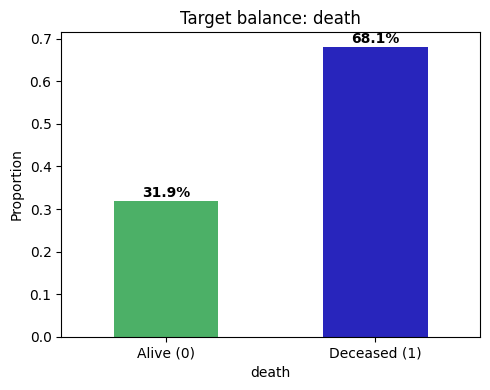

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 4))

counts = train['death'].value_counts(normalize=True).sort_index()
counts.plot(kind='bar', color=["#4CB067", "#2825BC"], ax=ax)

ax.set_xticklabels(['Alive (0)', 'Deceased (1)'], rotation=0)
ax.set_ylabel('Proportion')
ax.set_title('Target balance: death')

for i, v in enumerate(counts):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7284 entries, 0 to 7283
Data columns (total 46 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              7284 non-null   float64
 1   sex              7284 non-null   object 
 2   dzgroup          7284 non-null   object 
 3   dzclass          7284 non-null   object 
 4   num.co           7284 non-null   int64  
 5   edu              5986 non-null   float64
 6   income           4895 non-null   object 
 7   scoma            7283 non-null   float64
 8   charges          7143 non-null   float64
 9   totcst           6574 non-null   float64
 10  totmcst          4502 non-null   float64
 11  avtisst          7215 non-null   float64
 12  race             7255 non-null   object 
 13  sps              7283 non-null   float64
 14  aps              7283 non-null   float64
 15  surv2m           7283 non-null   float64
 16  surv6m           7283 non-null   float64
 17  hday          

In [7]:
train.describe()

,age,num.co,edu,scoma,charges,totcst,totmcst,avtisst,sps,aps,...,sod,ph,glucose,bun,urine,adlp,adls,adlsc,temp_f,death
count,7284.000000,7284.000000,5986.000000,7283.000000,7.143000e+03,6574.000000,4502.000000,7215.000000,7283.000000,7283.000000,...,7283.000000,5446.000000,3667.000000,3788.000000,3394.000000,2804.000000,4995.000000,7284.000000,7283.000000,7284.000000
mean,62.703488,1.881521,11.760942,11.960868,5.895153e+04,30403.185801,28068.586976,22.502055,25.505230,37.639160,...,137.574763,7.415452,159.108263,32.205042,2201.083776,1.160128,1.638038,1.892847,98.765961,0.681082
std,15.578490,1.346613,3.460746,24.622416,9.969796e+04,45056.838419,42146.191587,13.198801,9.923365,20.062816,...,6.054296,0.080806,87.844159,26.649913,1469.620701,1.753962,2.237571,2.013743,2.257479,0.466089
min,18.118990,0.000000,0.000000,0.000000,1.212000e+03,0.000000,-102.719970,1.000000,1.199951,1.000000,...,111.000000,6.829102,1.399902,1.000000,0.000000,0.000000,0.000000,0.000000,89.058596,0.000000
25%,52.879235,1.000000,10.000000,0.000000,9.541500e+03,5800.586950,5024.645507,12.000000,18.898438,23.000000,...,134.000000,7.379883,102.000000,14.000000,1170.000000,0.000000,0.000000,0.000000,97.151558,0.000000
50%,64.932465,2.000000,12.000000,0.000000,2.458700e+04,14126.816400,12814.714850,19.500000,23.898438,34.000000,...,137.000000,7.419922,134.000000,23.000000,1969.000000,0.000000,0.000000,1.000000,98.051558,1.000000
75%,74.059708,3.000000,14.000000,9.000000,6.389350e+04,35861.257825,33051.492225,31.666656,30.199219,48.000000,...,141.000000,7.469727,189.000000,42.000000,3019.750000,2.000000,3.000000,3.000000,100.568750,1.000000
max,100.849000,9.000000,31.000000,100.000000,1.435423e+06,633212.000000,710682.000000,83.000000,99.187500,143.000000,...,175.000000,7.769531,1092.000000,192.000000,9000.000000,7.000000,7.000000,7.073242,107.051558,1.000000


### 1: Duplicated rows

In [8]:
train.duplicated().sum() # -> there are no duplicates

0

### 2: Missing values in each feature

In [9]:
train.isnull().mean().sort_values(ascending=False)

adlp               0.615047
urine              0.534047
glucose            0.496568
bun                0.479956
totmcst            0.381933
alb                0.370401
income             0.327979
adls               0.314250
bili               0.288303
pafi               0.256452
ph                 0.252334
prg2m              0.179297
edu                0.178199
prg6m              0.177375
totcst             0.097474
wblc               0.023064
charges            0.019357
avtisst            0.009473
crea               0.007414
race               0.003981
dnr                0.003569
dnrday             0.003569
surv6m             0.000137
sod                0.000137
temp_f             0.000137
temp               0.000137
resp               0.000137
hrt                0.000137
sps                0.000137
meanbp             0.000137
aps                0.000137
surv2m             0.000137
scoma              0.000137
medical_center     0.000000
admission_month    0.000000
adlsc              0

### 3: Missing values in each rows

In [10]:
train.isnull().mean(axis=1).sort_values(ascending=False)*100

2202    41.304348
4955    39.130435
6124    36.956522
6426    30.434783
5403    30.434783
          ...    
1831     0.000000
5177     0.000000
5186     0.000000
6045     0.000000
1081     0.000000
Length: 7284, dtype: float64

Missing values in rows are not that high to allow cancellation

### 3: Correlation of numerical features with target

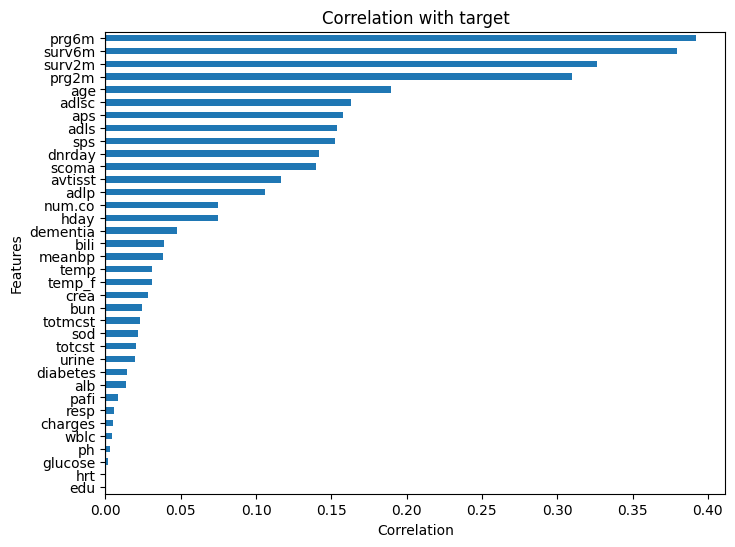

In [11]:
import matplotlib.pyplot as plt
corr_target = train.corr(numeric_only=True)["death"].drop("death")
corr_target = corr_target.abs().sort_values()

corr_target.plot(kind="barh", figsize=(8, 6))

plt.xlabel("Correlation")
plt.ylabel("Features")
plt.title("Correlation with target")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()

As we expected,  "surv2m", "surv6m","prg2m", "prg6m" are the most correlated because there are survival expectation predicted by an another model. It will be interesting to try to remove them to see if our model works well even without them

In [12]:
print(corr_target.sort_values(ascending=True).head(15))


edu         0.000125
hrt         0.000617
glucose     0.001401
ph          0.002914
wblc        0.004529
charges     0.005148
resp        0.005454
pafi        0.008101
alb         0.013361
diabetes    0.014319
urine       0.019470
totcst      0.020404
sod         0.021549
totmcst     0.023258
bun         0.024594
Name: death, dtype: float64


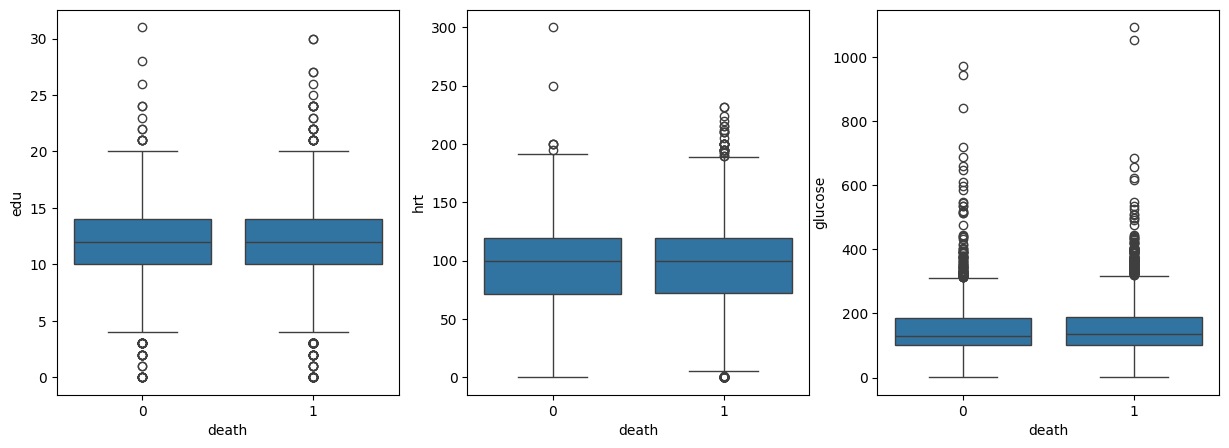

In [13]:
import seaborn as sns
fig, axes = plt.subplots(1,3, figsize=(15,5))
sns.boxplot(data=train, x="death", y="edu", ax=axes[0])
sns.boxplot(data=train, x="death", y="hrt", ax=axes[1])
sns.boxplot(data=train, x="death", y="glucose", ax=axes[2])
plt.show()

Here we can notice that features edu and hrt seems to be scorrelated to death, glucose instead is better (even if glucose is not highly correlated too...) these are candidates to be dropped for our classification.

### 4: split features in numerical, ordinal, categorical and binary

In [14]:
train_num = ["age", "scoma", "charges", "totcst", "totmcst",
    "avtisst", "sps", "aps", "surv2m", "surv6m","prg2m", "prg6m", "hday", "dnrday",
    "meanbp", "wblc", "hrt", "resp", "temp","temp_f", "pafi","alb","crea","ph", "glucose", "bun",
    "adls","adlsc", "adlp","edu", "bili","urine","sod"]

train_binary = ["diabetes","dementia"]

train_ord = ["ca","income","num.co"]

train_cat = ["sex", "dzgroup", "dzclass", "race", "dnr", "medical_center",
    "admission_month"]

target = ["death"]

#### Numerical Features

Correlation between features

In [15]:
import numpy as np
corr = train[train_num].corr()


corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(ascending=False)
)

print(corr_pairs.head(15))

adls     adlsc      1.000000
temp     temp_f     1.000000
surv2m   surv6m     0.960284
totcst   totmcst    0.943649
prg2m    prg6m      0.895613
charges  totcst     0.878120
         totmcst    0.806597
sps      aps        0.802220
totcst   dnrday     0.742850
totmcst  dnrday     0.730559
crea     bun        0.689582
adlsc    adlp       0.681154
adls     adlp       0.639028
charges  dnrday     0.629103
avtisst  aps        0.600557
dtype: float64


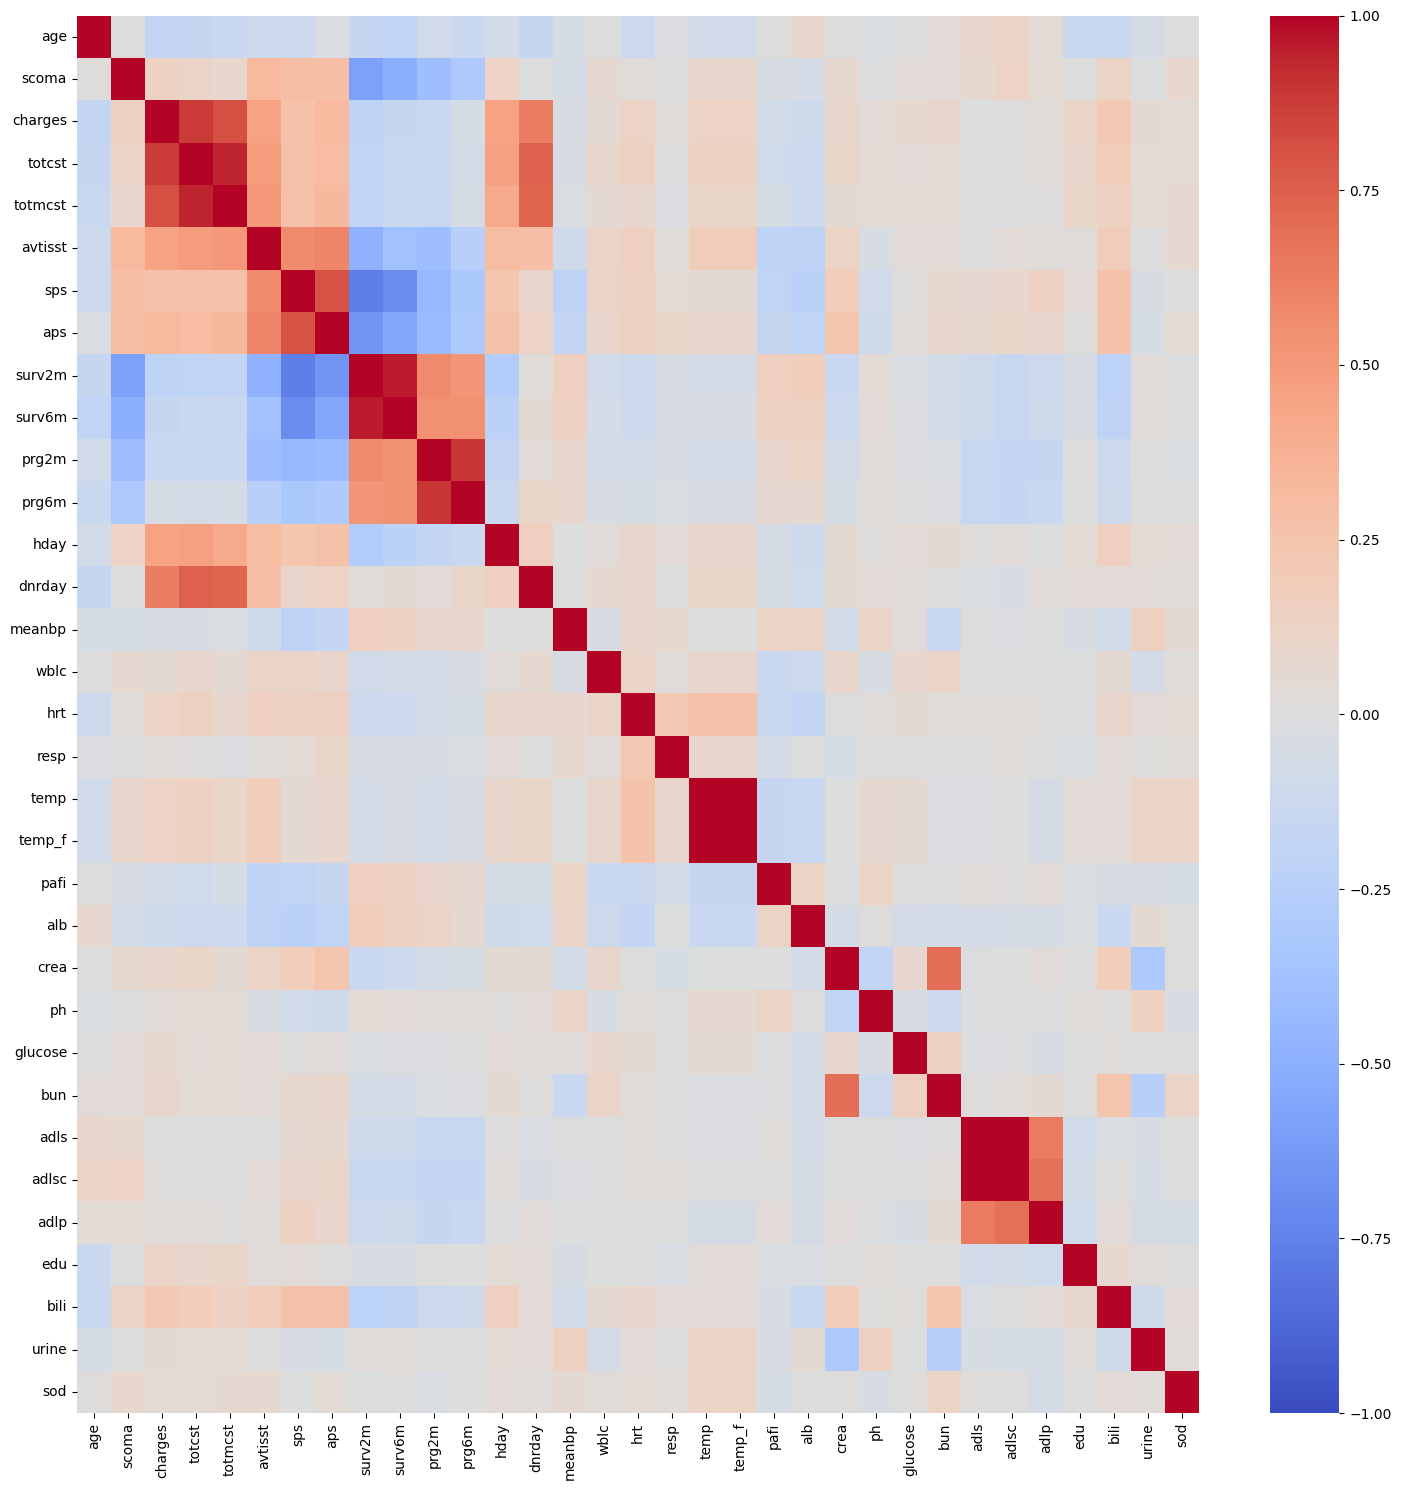

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 15))
sns.heatmap(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.tight_layout()
plt.show()

#### Categorical Features

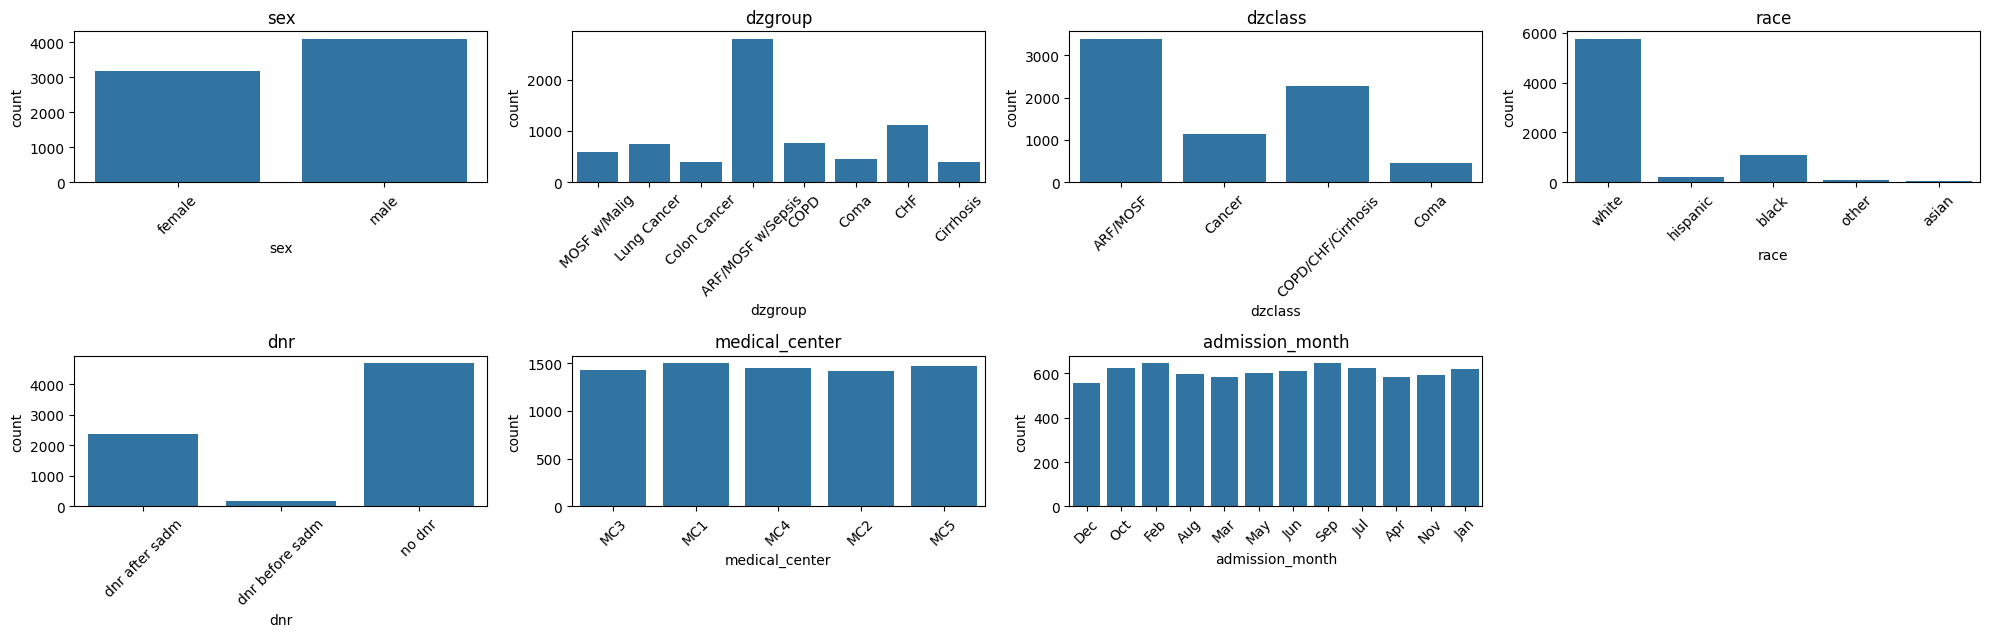

In [17]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(train_cat):
    plt.subplot(5, 4, i + 1)
    sns.countplot(x=train[col])
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

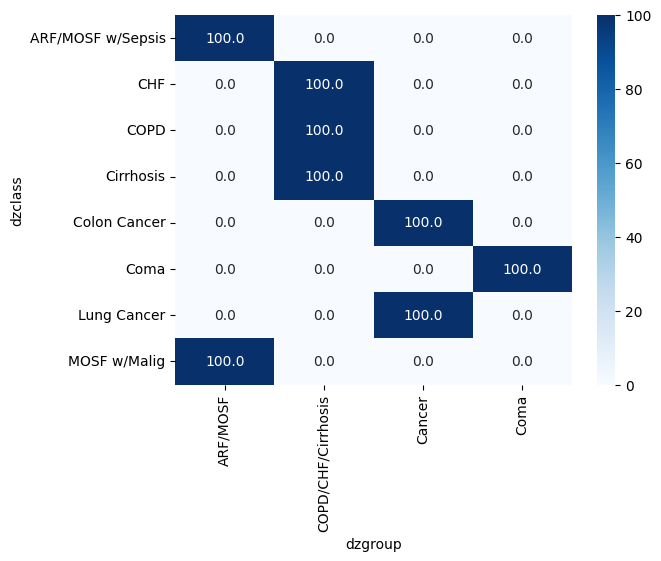

In [18]:
table = pd.crosstab(
    train["dzgroup"],
    train["dzclass"],
    normalize="index"
) * 100

sns.heatmap(table, annot=True, fmt=".1f", cmap="Blues")
plt.xlabel("dzgroup")
plt.ylabel("dzclass")
plt.show()

As we could notice in the feature description, dzgroup and dzclass are redundant. We can test if it's better to keep them or not

#### Ordinal features

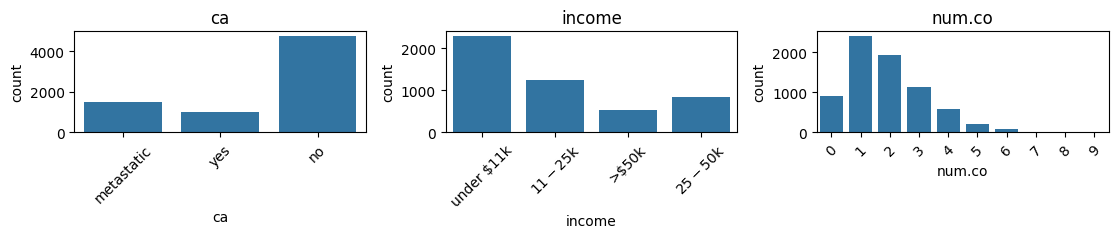

In [19]:
plt.figure(figsize=(15,10))
for i, col in enumerate(train_ord):
    plt.subplot(5, 4, i + 1)
    sns.countplot(x=train[col])
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

#### Binary Features

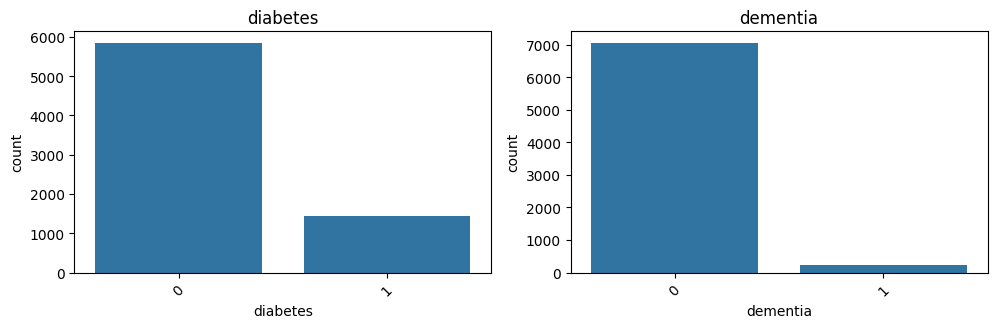

In [20]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(train_binary):
    plt.subplot(5, 4, i + 1)
    sns.countplot(x=train[col])
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

## To conclude preprocessing:
- features that we have to test to see if they increase f1 score are: 'adls', 'adlp', 'surv2m','totmcst', 'dzgroup', 'edu', 'hrt'
- features that we have to delete are: 'Id', 'temp_f'

In [22]:
import model  

# Split dataset in features X and target y
y = train['death'] # -> death = target
X = train.drop(columns = ['death'])

#  Select best model
results_df, fitted_pipelines = model.select_best_model(X, y)


[full           | LogisticRegression  ] CV f1_macro = 0.7369
[reduced_edu    | LogisticRegression  ] CV f1_macro = 0.7374
[reduced_adls+adlp | LogisticRegression  ] CV f1_macro = 0.7362
[reduced_hrt_edu | LogisticRegression  ] CV f1_macro = 0.7369
[reduced_totcst | LogisticRegression  ] CV f1_macro = 0.7372
[reduced_class  | LogisticRegression  ] CV f1_macro = 0.7358
[reduced_all    | LogisticRegression  ] CV f1_macro = 0.7359
[full           | HistGradientBoosting] CV f1_macro = 0.7513 
[reduced_edu    | HistGradientBoosting] CV f1_macro = 0.7527 
[reduced_adls+adlp | HistGradientBoosting] CV f1_macro = 0.7514 
[reduced_hrt_edu | HistGradientBoosting] CV f1_macro = 0.7486 
[reduced_totcst | HistGradientBoosting] CV f1_macro = 0.7543 
[reduced_class  | HistGradientBoosting] CV f1_macro = 0.7510 
[reduced_all    | HistGradientBoosting] CV f1_macro = 0.7515 


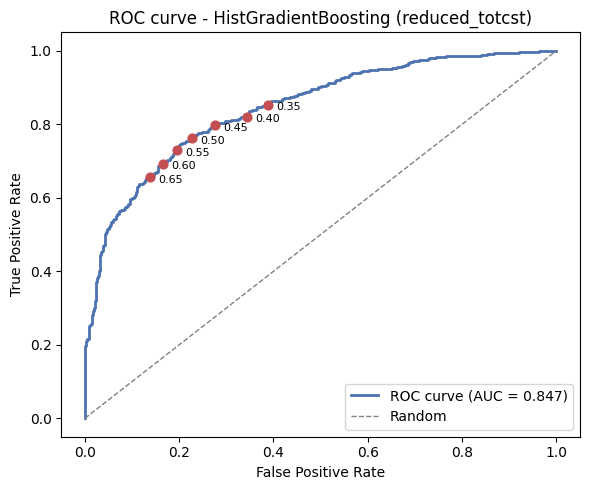

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.base import clone
import matplotlib.pyplot as plt


best_row = results_df.iloc[0]
config_name = best_row.config
model_name = best_row.model

roc_pipeline = clone(fitted_pipelines[(model_name, config_name)])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

roc_pipeline.fit(X_train, y_train)
proba_val = roc_pipeline.predict_proba(X_val)[:, 1]

fpr, tpr, roc_thresholds = roc_curve(y_val, proba_val)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="#4C72B0", linewidth=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Random")

candidate_thresholds = [0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]
for t in candidate_thresholds:
    idx = (abs(roc_thresholds - t)).argmin()
    plt.scatter(fpr[idx], tpr[idx], color="#C44E52", zorder=5, s=40)
    plt.annotate(f"{t:.2f}", (fpr[idx], tpr[idx]),
                 textcoords="offset points", xytext=(6, -4), fontsize=8)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC curve - {model_name} ({config_name})")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

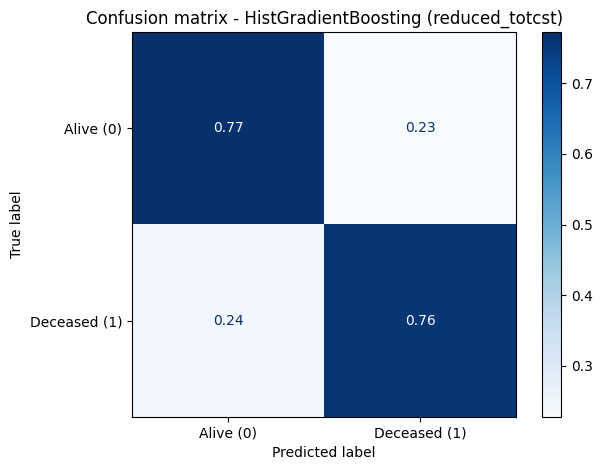


Classification report (validation set):
              precision    recall  f1-score   support

   Alive (0)       0.60      0.77      0.68       465
Deceased (1)       0.88      0.76      0.81       992

    accuracy                           0.76      1457
   macro avg       0.74      0.77      0.74      1457
weighted avg       0.79      0.76      0.77      1457



In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_pred_val = (proba_val >= 0.5).astype(int)

cm = confusion_matrix(y_val, y_pred_val, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Alive (0)", "Deceased (1)"])
disp.plot(cmap="Blues")
plt.title(f"Confusion matrix - {model_name} ({config_name})")
plt.tight_layout()
plt.show()

print("\nClassification report (validation set):")
print(classification_report(y_val, y_pred_val, target_names=["Alive (0)", "Deceased (1)"]))